Dataset Overview: DAIC-WOZ (Segmented Audio Experiment)
**Pipeline**: Klasifikasi Kesehatan Mental Berbasis Audio (DAIC-WOZ) - Segmentasi 10 Detik
**Peran**: ML & Data Engineer — Athila Ramdani Saputra

**Eksperimen**:
Melakukan segmentasi audio bersih menjadi potongan-potongan pendek berdurasi 10 detik.
Model dilatih pada tingkat segmen untuk meningkatkan jumlah sampel latih, namun
dievaluasi pada tingkat partisipan (menggunakan rata-rata probabilitas segmen) agar
performanya tetap sebanding dengan splits resmi DAIC-WOZ.

Model yang dilatih:
1. Logistic Regression
2. Support Vector Machine (SVM)
3. Random Forest
4. XGBoost
Menggunakan GridSearchCV dengan GroupKFold Cross-Validation (anti-leakage berdasarkan participant_id).


In [1]:
import os
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython_fn = globals().get('get_ipython', None)
    if get_ipython_fn is None:
        import builtins
        get_ipython_fn = getattr(builtins, 'get_ipython', None)
        
    if get_ipython_fn is not None:
        cfg = get_ipython_fn().__class__.__name__
        if cfg != 'ZMQInteractiveShell':
            matplotlib.use('Agg')
    else:
        matplotlib.use('Agg')
except Exception:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, roc_auc_score)
from sklearn.feature_selection import f_classif, mutual_info_classif
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set font family for plots
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Library berhasil diimport.")


Library berhasil diimport.


In [2]:
# Konfigurasi Path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if "notebooks" in os.getcwd() else os.getcwd()

CLEANED_DIR = os.path.join(PROJECT_ROOT, "data", "cleaned")
FEATURES_DIR = os.path.join(PROJECT_ROOT, "data", "features", "mfcc")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models", "ml")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR, "svm"), exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR, "random_forest"), exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR, "xgboost"), exist_ok=True)

os.makedirs(os.path.join(RESULTS_DIR, "metrics"), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "plots"), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "confusion_matrix"), exist_ok=True)

# Path unik untuk Eksperimen Segmentasi (v3)
FINAL_FEATURES_PATH = os.path.join(FEATURES_DIR, "daic_features_segmented_final.csv")
FEATURE_LIST_PATH = os.path.join(FEATURES_DIR, "daic_feature_list_segmented.txt")

# Set FORCE_EXTRACT to True if you want to rerun the feature extraction pipeline
FORCE_EXTRACT = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Features file: {FINAL_FEATURES_PATH}")


Project root: d:\repositories\menthealth-ai
Features file: d:\repositories\menthealth-ai\data\features\mfcc\daic_features_segmented_final.csv


## 0. Audio Feature Extraction Pipeline (Segmented 10s)
Bagian ini membagi audio secara berurutan menjadi segmen berdurasi 10 detik sebelum melakukan ekstraksi fitur.


In [3]:
# Konfigurasi Parameter Audio
TARGET_SR = 16000
N_MFCC = 13
FRAME_LENGTH = int(0.025 * TARGET_SR)  # 25ms window
HOP_LENGTH = int(0.010 * TARGET_SR)    # 10ms hop
SEGMENT_DURATION_SEC = 10              # Segmen 10 detik

def calculate_jitter_shimmer_manual(y, sr, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH):
    """
    Estimasi jitter dan shimmer secara manual dari waveform suara voiced frames.
    """
    try:
        pitches, magnitudes = librosa.piptrack(
            y=y, sr=sr, n_fft=frame_length, hop_length=hop_length,
            fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7')
        )
        
        pitch_vals = []
        voiced_frames = []
        for t in range(pitches.shape[1]):
            idx = magnitudes[:, t].argmax()
            p = pitches[idx, t]
            if p > 50.0:  # Valid pitch threshold
                pitch_vals.append(p)
                voiced_frames.append(t)
        
        if len(pitch_vals) < 2:
            return 0.0, 0.0
        
        pitch_vals = np.array(pitch_vals)
        periods = 1.0 / pitch_vals
        
        # Jitter Local (%)
        jitter = (np.mean(np.abs(np.diff(periods))) / np.mean(periods)) * 100
        
        # Shimmer Local (%)
        rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        voiced_rms = []
        for frame in voiced_frames:
            if frame < len(rms):
                val = rms[frame]
                if val > 0:
                    voiced_rms.append(val)
        
        if len(voiced_rms) < 2:
            shimmer = 0.0
        else:
            voiced_rms = np.array(voiced_rms)
            shimmer = (np.mean(np.abs(np.diff(voiced_rms))) / np.mean(voiced_rms)) * 100
            
        return float(jitter), float(shimmer)
    except Exception:
        return 0.0, 0.0

def aggregate_feature(feat_array, name):
    """
    Agregasi data frame-level ke summary statistics.
    """
    if len(feat_array) == 0:
        return {
            f'{name}_mean': 0.0, f'{name}_std': 0.0, f'{name}_min': 0.0,
            f'{name}_max': 0.0, f'{name}_p25': 0.0, f'{name}_p75': 0.0
        }
    return {
        f'{name}_mean': float(np.mean(feat_array)),
        f'{name}_std': float(np.std(feat_array)),
        f'{name}_min': float(np.min(feat_array)),
        f'{name}_max': float(np.max(feat_array)),
        f'{name}_p25': float(np.percentile(feat_array, 25)),
        f'{name}_p75': float(np.percentile(feat_array, 75))
    }

def extract_all_audio_features(y, sr):
    """
    Ekstrak fitur akustik dari audio tingkat segmen.
    """
    features = {}
    
    # 1. MFCC
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
    for i in range(N_MFCC):
        features.update(aggregate_feature(mfccs[i], f'mfcc_{i+1}'))
        
    # 2. Pitch / F0
    try:
        pitches, magnitudes = librosa.piptrack(
            y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH,
            fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7')
        )
        pitch_vals = []
        for t in range(pitches.shape[1]):
            idx = magnitudes[:, t].argmax()
            p = pitches[idx, t]
            if p > 0:
                pitch_vals.append(p)
        features.update(aggregate_feature(np.array(pitch_vals) if pitch_vals else np.array([0.0]), 'pitch'))
    except Exception:
        features.update(aggregate_feature(np.array([0.0]), 'pitch'))
        
    # 3. RMS Energy
    rms = librosa.feature.rms(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    features.update(aggregate_feature(rms, 'rms_energy'))
    
    # 4. Spectral Centroid
    cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    features.update(aggregate_feature(cent, 'spectral_centroid'))
    
    # 5. Spectral Bandwidth
    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    features.update(aggregate_feature(bw, 'spectral_bandwidth'))
    
    # 6. Spectral Rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    features.update(aggregate_feature(rolloff, 'spectral_rolloff'))
    
    # 7. ZCR
    zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    features.update(aggregate_feature(zcr, 'zcr'))
    
    # 8. Jitter/Shimmer
    jitter, shimmer = calculate_jitter_shimmer_manual(y, sr)
    features['jitter'] = jitter
    features['shimmer'] = shimmer
    
    return features

def map_label_strategi_v1(row):
    """
    Pelabelan biner berdasarkan PHQ-8 score (0: Normal/Non-Depresi, 1: Depresi)
    """
    phq_binary = row.get('PHQ8_Binary', row.get('PHQ_Binary', np.nan))
    if not pd.isna(phq_binary):
        return int(phq_binary)
        
    phq_score = row.get('PHQ8_Score', row.get('PHQ_Score', np.nan))
    if pd.isna(phq_score):
        phq_score = 0
    else:
        phq_score = int(phq_score)
        
    return 1 if phq_score >= 10 else 0

def build_segmented_dataset_and_extract_features(cleaned_dir, output_dir, segment_duration_sec=SEGMENT_DURATION_SEC):
    """
    Membangun dataset fitur berbasis segmen berdurasi 10 detik dari audio bersih.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    raw_dir = os.path.join(os.path.dirname(cleaned_dir), "raw", "DAIC-WOZ")
    train_split_path = os.path.join(raw_dir, "train_split_Depression_AVEC2017.csv")
    dev_split_path = os.path.join(raw_dir, "dev_split_Depression_AVEC2017.csv")
    test_split_path = os.path.join(raw_dir, "full_test_split.csv")
    
    if not (os.path.exists(train_split_path) and os.path.exists(dev_split_path) and os.path.exists(test_split_path)):
        raise FileNotFoundError(f"File split metadata resmi tidak ditemukan di {raw_dir}")
        
    df_train = pd.read_csv(train_split_path)
    df_dev = pd.read_csv(dev_split_path)
    df_test = pd.read_csv(test_split_path)
    
    df_train.columns = [col.strip() for col in df_train.columns]
    df_dev.columns = [col.strip() for col in df_dev.columns]
    df_test.columns = [col.strip() for col in df_test.columns]
    
    df_train['label_depresi'] = df_train.apply(map_label_strategi_v1, axis=1)
    df_dev['label_depresi'] = df_dev.apply(map_label_strategi_v1, axis=1)
    df_test['label_depresi'] = df_test.apply(map_label_strategi_v1, axis=1)
    
    df_train['split'] = 'train'
    df_dev['split'] = 'dev'
    df_test['split'] = 'test'
    
    for df_part in [df_train, df_dev, df_test]:
        for col in df_part.columns:
            if col.lower() == 'participant_id':
                df_part.rename(columns={col: 'Participant_ID'}, inplace=True)
        if 'PHQ_Score' not in df_part.columns and 'PHQ8_Score' in df_part.columns:
            df_part['PHQ_Score'] = df_part['PHQ8_Score']
        elif 'PHQ8_Score' not in df_part.columns and 'PHQ_Score' in df_part.columns:
            df_part['PHQ8_Score'] = df_part['PHQ_Score']
            
    all_metadata = []
    meta_cols_to_keep = ['Participant_ID', 'PHQ8_Score', 'PHQ_Score', 'label_depresi', 'split', 'Gender']
    for df_part in [df_train, df_dev, df_test]:
        cols_avail = [c for c in meta_cols_to_keep if c in df_part.columns]
        all_metadata.append(df_part[cols_avail])
        
    df_meta_combined = pd.concat(all_metadata, ignore_index=True)
    df_meta_combined.rename(columns={'Participant_ID': 'participant_id'}, inplace=True)
    
    print(f"Total partisipan terdaftar di metadata: {len(df_meta_combined)}")
    
    dataset_rows = []
    success_count = 0
    cleaned_files = [f for f in os.listdir(cleaned_dir) if f.endswith('.wav')]
    print(f"Ditemukan {len(cleaned_files)} file audio bersih di {cleaned_dir}")
    
    print("\n" + "="*115)
    print(f"{'TABEL DATA EKSTRAKSI FITUR SEGMENTASI AKUSTIK (10s)':^115}")
    print("="*115)
    print(f"{'PARTICIPANT ID':14s} | {'SEGMENTS':8s} | {'DIAGNOSIS':9s} | {'PITCH (Mean)':12s} | {'JITTER':8s} | {'SHIMMER':8s} | {'STATUS':6s}")
    print("-"*115)
    
    segment_len_samples = segment_duration_sec * TARGET_SR
    
    for file in cleaned_files:
        participant_id = int(file.replace('.wav', ''))
        meta_row = df_meta_combined[df_meta_combined['participant_id'] == participant_id]
        if meta_row.empty:
            continue
            
        audio_path = os.path.join(cleaned_dir, file)
        transcript_path = os.path.join(raw_dir, f"{participant_id}_P", f"{participant_id}_TRANSCRIPT.csv")
        
        try:
            y, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)
            if len(y) < segment_len_samples:
                # Jika audio lebih pendek dari durasi 1 segmen, jadikan 1 segmen utuh
                segments_y = [y]
            else:
                segments_y = []
                num_segments = len(y) // segment_len_samples
                for i in range(num_segments):
                    segments_y.append(y[i * segment_len_samples : (i + 1) * segment_len_samples])
            
            # Global conversational features to replicate to each segment row
            original_duration = 0.0
            cleaned_duration = len(y) / sr
            speech_ratio = 0.0
            participant_turns = 0
            ellie_turns = 0
            
            if os.path.exists(transcript_path):
                try:
                    try:
                        df_trans = pd.read_csv(transcript_path, sep='\t')
                    except Exception:
                        df_trans = pd.read_csv(transcript_path)
                    
                    df_trans.columns = [col.lower().strip() for col in df_trans.columns]
                    part_turns = df_trans[df_trans['speaker'].str.lower().str.strip() == 'participant']
                    ellie_turns_df = df_trans[df_trans['speaker'].str.lower().str.strip() == 'ellie']
                    participant_turns = len(part_turns)
                    ellie_turns = len(ellie_turns_df)
                    part_duration = (part_turns['stop_time'] - part_turns['start_time']).sum()
                    total_duration = df_trans['stop_time'].max() if len(df_trans) > 0 else 1.0
                    original_duration = float(total_duration)
                    cleaned_duration = float(part_duration)
                    speech_ratio = float(part_duration / total_duration)
                except Exception:
                    pass
            
            last_pitch_mean = 0.0
            last_jitter = 0.0
            last_shimmer = 0.0
            
            for seg_idx, y_seg in enumerate(segments_y):
                if len(y_seg) < TARGET_SR:  # Abaikan sisa segmen yang terlalu pendek (< 1s)
                    continue
                features = extract_all_audio_features(y_seg, sr)
                
                # Conversational features
                features['original_duration_sec'] = original_duration
                features['cleaned_duration_sec'] = cleaned_duration
                features['speech_ratio'] = speech_ratio
                features['participant_turns'] = float(participant_turns)
                features['ellie_turns'] = float(ellie_turns)
                
                # Metadata
                features['participant_id'] = participant_id
                features['segment_id'] = f"{participant_id}_seg_{seg_idx}"
                features['phq8_score'] = int(meta_row.iloc[0]['PHQ8_Score'])
                features['label_depresi'] = int(meta_row.iloc[0]['label_depresi'])
                features['split'] = meta_row.iloc[0]['split']
                features['gender'] = int(meta_row.iloc[0]['Gender'])
                
                dataset_rows.append(features)
                success_count += 1
                
                last_pitch_mean = features.get('pitch_mean', 0.0)
                last_jitter = features.get('jitter', 0.0)
                last_shimmer = features.get('shimmer', 0.0)
                
            # Print table row summary for the participant
            label_str = "Depresi" if meta_row.iloc[0]['label_depresi'] == 1 else "Normal"
            print(f"PID {participant_id:03d}          | {len(segments_y):3d} segs | {label_str:9s} | {last_pitch_mean:6.1f} Hz   | {last_jitter:5.2f} %  | {last_shimmer:5.2f} %  | OK", flush=True)
            
        except Exception as e:
            print(f"PID {participant_id:03d}          | Error    | {'ERROR':9s} | {'-':12s} | {'-':8s} | {'-':8s} | ERROR: {e}", flush=True)
            
    print("="*115 + "\n")
            
    df_features = pd.DataFrame(dataset_rows)
    
    META_COLS = ['participant_id', 'segment_id', 'phq8_score', 'label_depresi', 'split', 'gender']
    FEAT_COLS = [col for col in df_features.columns if col not in META_COLS]
    df_features = df_features[META_COLS + FEAT_COLS]
    
    raw_csv_path = os.path.join(output_dir, "daic_features_segmented_raw.csv")
    df_features.to_csv(raw_csv_path, index=False)
    
    # Cleaning
    df_features[FEAT_COLS] = df_features[FEAT_COLS].fillna(df_features[FEAT_COLS].median())
    std_vals = df_features[FEAT_COLS].std()
    const_feats = std_vals[std_vals < 1e-8].index.tolist()
    FEAT_COLS = [f for f in FEAT_COLS if f not in const_feats]
    
    Q1 = df_features[FEAT_COLS].quantile(0.25)
    Q3 = df_features[FEAT_COLS].quantile(0.75)
    IQR = Q3 - Q1
    for col in FEAT_COLS:
        lower = Q1[col] - 10 * IQR[col]
        upper = Q3[col] + 10 * IQR[col]
        df_features[col] = df_features[col].clip(lower=lower, upper=upper)
        
    corr_matrix = df_features[FEAT_COLS].corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
    FEAT_COLS_FILTERED = [f for f in FEAT_COLS if f not in to_drop]
    
    # Feature selection on Train split
    train_mask = df_features['split'] == 'train'
    df_train_feats = df_features[train_mask]
    X_train = df_train_feats[FEAT_COLS_FILTERED].values
    y_train = df_train_feats['label_depresi'].values
    
    f_scores, p_values = f_classif(X_train, y_train)
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    
    df_selection = pd.DataFrame({
        'feature': FEAT_COLS_FILTERED,
        'p_value': p_values,
        'mi_score': mi_scores,
        'significant': p_values < 0.05
    })
    
    sig_feats = df_selection[df_selection['significant']]['feature'].tolist()
    top_mi_feats = df_selection.sort_values('mi_score', ascending=False).head(50)['feature'].tolist()
    
    final_feats = list(set(sig_feats) | set(top_mi_feats))
    final_feats = [f for f in FEAT_COLS_FILTERED if f in final_feats]
    
    feat_list_path = os.path.join(output_dir, "daic_feature_list_segmented.txt")
    with open(feat_list_path, 'w') as f:
        f.write('\n'.join(final_feats))
        
    df_final = df_features[META_COLS + final_feats]
    final_csv_path = os.path.join(output_dir, "daic_features_segmented_final.csv")
    df_final.to_csv(final_csv_path, index=False)
    print(f"Matriks fitur segmen final berhasil diekstrak dan disimpan di: {final_csv_path} (Shape: {df_final.shape})")
    
    print("Distribusi kelas (tingkat segmen):")
    for split_name in ['train', 'dev', 'test']:
        counts = df_final[df_final['split'] == split_name]['label_depresi'].value_counts().sort_index()
        print(f"  {split_name.upper()}: {dict(counts)}")


## 1. Load Data & Scaling (Lazy Run Logic)


In [4]:
if FORCE_EXTRACT or not os.path.exists(FINAL_FEATURES_PATH):
    print("\n[INFO] Memulai ekstraksi fitur akustik segmen (10s) secara otomatis...")
    build_segmented_dataset_and_extract_features(CLEANED_DIR, FEATURES_DIR)
else:
    print(f"\n[INFO] Menggunakan matriks fitur segmen yang sudah ada di: {FINAL_FEATURES_PATH}")

df = pd.read_csv(FINAL_FEATURES_PATH)

with open(FEATURE_LIST_PATH, 'r') as f:
    FEAT_COLS = [line.strip() for line in f.readlines() if line.strip()]

FEAT_COLS = [f for f in FEAT_COLS if f in df.columns]

META_COLS = ['participant_id', 'segment_id', 'phq8_score', 'label_depresi', 'split', 'gender']

print(f"Shape dataset segmen final: {df.shape}")
print(f"Jumlah fitur final: {len(FEAT_COLS)}")

# Split data based on split column
df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_dev = df[df['split'] == 'dev'].reset_index(drop=True)
df_test = df[df['split'] == 'test'].reset_index(drop=True)

print(f"\nJumlah Baris Segmen:")
print(f"  Train: {len(df_train)}")
print(f"  Dev  : {len(df_dev)}")
print(f"  Test : {len(df_test)}")



[INFO] Memulai ekstraksi fitur akustik segmen (10s) secara otomatis...
Total partisipan terdaftar di metadata: 189
Ditemukan 102 file audio bersih di d:\repositories\menthealth-ai\data\cleaned

                                TABEL DATA EKSTRAKSI FITUR SEGMENTASI AKUSTIK (10s)                                
PARTICIPANT ID | SEGMENTS | DIAGNOSIS | PITCH (Mean) | JITTER   | SHIMMER  | STATUS
-------------------------------------------------------------------------------------------------------------------
PID 300          |  15 segs | Normal    |  369.9 Hz   | 24.30 %  | 14.06 %  | OK
PID 301          |  47 segs | Normal    |  362.7 Hz   | 31.42 %  | 15.81 %  | OK
PID 302          |  20 segs | Normal    |  294.2 Hz   | 24.76 %  | 13.41 %  | OK
PID 303          |  64 segs | Normal    |  428.5 Hz   | 22.06 %  | 17.62 %  | OK
PID 304          |  36 segs | Normal    |  376.8 Hz   | 24.44 %  | 15.47 %  | OK
PID 305          |  43 segs | Normal    |  331.4 Hz   | 33.08 %  | 14.59 %  | OK
PID

In [5]:
# Extract features and labels for segment-level training
X_train = df_train[FEAT_COLS].values
y_train = df_train['label_depresi'].values
groups_train = df_train['participant_id'].values

# Fit scaler ONLY on train segments
scaler = StandardScaler()
scaler.fit(X_train)

# Save scaler
scaler_path = os.path.join(MODELS_DIR, "scaler_v3.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler berhasil di-fit dan disimpan di: {scaler_path}")

# Scale train segments
X_train_scaled = scaler.transform(X_train)


Scaler berhasil di-fit dan disimpan di: d:\repositories\menthealth-ai\models\ml\scaler_v3.pkl


## 2. Definisi Model & Hyperparameter Grid


In [6]:
RANDOM_SEED = 42

MODELS = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced'),
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'SVM (RBF)': {
        'model': SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED, class_weight='balanced', decision_function_shape='ovr'),
        'param_grid': {
            'C': [0.1, 1.0, 10.0, 100.0],
            'gamma': ['scale', 'auto']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced', n_jobs=-1),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', objective='binary:logistic', n_jobs=-1),
        'param_grid': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.05, 0.1]
        }
    }
}

print("Model dan grid hyperparameter berhasil didefinisikan:")
for model_name in MODELS.keys():
    print(f"  - {model_name}")


Model dan grid hyperparameter berhasil didefinisikan:
  - Logistic Regression
  - SVM (RBF)
  - Random Forest
  - XGBoost


## 3. Evaluasi Tingkat Partisipan dengan Rata-rata Probabilitas Segmen


In [7]:
def evaluate_participant_level(model, df_split, FEAT_COLS, scaler, prefix=''):
    """
    Melakukan evaluasi pada tingkat partisipan (bukan segmen).
    Mengagregasikan probabilitas prediksi dari seluruh segmen milik seorang partisipan
    dengan metode Mean Probability Voting (Mirip dengan Majority Voting).
    """
    X_split = df_split[FEAT_COLS].values
    X_split_scaled = scaler.transform(X_split)
    
    # Dapatkan probabilitas kelas 1 (Depresi) untuk setiap segmen
    try:
        probs = model.predict_proba(X_split_scaled)[:, 1]
    except Exception:
        probs = model.predict(X_split_scaled)
        
    df_temp = df_split[['participant_id', 'label_depresi']].copy()
    df_temp['pred_prob'] = probs
    
    # Rata-ratakan probabilitas segmen per partisipan
    df_grouped = df_temp.groupby('participant_id').agg({
        'label_depresi': 'first',
        'pred_prob': 'mean'
    }).reset_index()
    
    # Prediksi biner akhir (ambang batas 0.5)
    df_grouped['pred_class'] = (df_grouped['pred_prob'] >= 0.5).astype(int)
    
    y_true = df_grouped['label_depresi'].values
    y_pred = df_grouped['pred_class'].values
    y_prob = df_grouped['pred_prob'].values
    
    try:
        auc = float(roc_auc_score(y_true, y_prob))
    except Exception:
        auc = 0.0
        
    return {
        f'{prefix}accuracy': float(accuracy_score(y_true, y_pred)),
        f'{prefix}f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}f1_weighted': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        f'{prefix}precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}recall_macro': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}roc_auc': auc
    }, y_true, y_pred


## 4. Pelatihan dengan GroupKFold Cross-Validation


In [8]:
# 5-Fold GroupKFold Cross-Validation (berbasis participant_id agar segmen tidak bocor)
cv_splitter = GroupKFold(n_splits=5)

results = {}
best_models = {}
best_predictions = {}

print("="*65)
print(f"{'MULAI TRAINING DAN TUNING MODEL BERBASIS SEGMEN':^65}")
print("="*65)

for model_name, config in MODELS.items():
    print(f"\nTraining {model_name}...")
    
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['param_grid'],
        cv=cv_splitter,
        scoring='f1_macro',
        n_jobs=-1,
        refit=True
    )
    
    # Fit pada data segmen latih
    grid_search.fit(X_train_scaled, y_train, groups=groups_train)
    best_model = grid_search.best_estimator_
    
    # Evaluasi tingkat partisipan (agregasi segmen)
    train_metrics, _, _ = evaluate_participant_level(best_model, df_train, FEAT_COLS, scaler, 'train_')
    dev_metrics, _, _ = evaluate_participant_level(best_model, df_dev, FEAT_COLS, scaler, 'val_')
    test_metrics, y_true_test, y_pred_test = evaluate_participant_level(best_model, df_test, FEAT_COLS, scaler, 'test_')
    
    print(f"  Parameter Terbaik: {grid_search.best_params_}")
    print(f"  Best CV Macro F1 : {grid_search.best_score_:.4f}")
    print(f"  Val Macro F1     : {dev_metrics['val_f1_macro']:.4f} (Acc: {dev_metrics['val_accuracy']:.4f})")
    print(f"  Test Macro F1    : {test_metrics['test_f1_macro']:.4f} (Acc: {test_metrics['test_accuracy']:.4f})")
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_cv_f1': float(grid_search.best_score_),
        **train_metrics,
        **dev_metrics,
        **test_metrics
    }
    best_models[model_name] = best_model
    best_predictions[model_name] = (y_true_test, y_pred_test)

print("\n[INFO] Pelatihan seluruh model selesai.")


         MULAI TRAINING DAN TUNING MODEL BERBASIS SEGMEN         

Training Logistic Regression...
  Parameter Terbaik: {'C': 10.0, 'solver': 'liblinear'}
  Best CV Macro F1 : 0.5488
  Val Macro F1     : 0.4643 (Acc: 0.4667)
  Test Macro F1    : 0.6349 (Acc: 0.6522)

Training SVM (RBF)...
  Parameter Terbaik: {'C': 0.1, 'gamma': 'auto'}
  Best CV Macro F1 : 0.5594
  Val Macro F1     : 0.5833 (Acc: 0.6000)
  Test Macro F1    : 0.4866 (Acc: 0.5652)

Training Random Forest...
  Parameter Terbaik: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
  Best CV Macro F1 : 0.5072
  Val Macro F1     : 0.4000 (Acc: 0.4667)
  Test Macro F1    : 0.3030 (Acc: 0.4348)

Training XGBoost...
  Parameter Terbaik: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50}
  Best CV Macro F1 : 0.5399
  Val Macro F1     : 0.4000 (Acc: 0.4667)
  Test Macro F1    : 0.4250 (Acc: 0.4783)

[INFO] Pelatihan seluruh model selesai.


## 5. Perbandingan Model & Evaluasi Akhir (Tingkat Partisipan)


In [9]:
# Build comparison DataFrame
comparison_rows = []
for name, res in results.items():
    comparison_rows.append({
        'Model': name,
        'CV Macro F1': res['best_cv_f1'],
        'Val Accuracy': res['val_accuracy'],
        'Val Macro F1': res['val_f1_macro'],
        'Test Accuracy': res['test_accuracy'],
        'Test Macro F1': res['test_f1_macro'],
        'Test Weighted F1': res['test_f1_weighted'],
        'Test Precision': res['test_precision_macro'],
        'Test Recall': res['test_recall_macro'],
        'Test ROC-AUC': res['test_roc_auc']
    })

df_compare = pd.DataFrame(comparison_rows)
comparison_csv = os.path.join(RESULTS_DIR, "metrics", "daic_model_comparison_v3.csv")
df_compare.to_csv(comparison_csv, index=False)

print("\n" + "="*65)
print(f"{'RINGKASAN HASIL PERBANDINGAN MODEL (TINGKAT PARTISIPAN - v3)':^65}")
print("="*65)
print(df_compare.round(4).to_string(index=False))
print(f"\nPerbandingan metrik disimpan di: {comparison_csv}")



  RINGKASAN HASIL PERBANDINGAN MODEL (TINGKAT PARTISIPAN - v3)   
              Model  CV Macro F1  Val Accuracy  Val Macro F1  Test Accuracy  Test Macro F1  Test Weighted F1  Test Precision  Test Recall  Test ROC-AUC
Logistic Regression       0.5488        0.4667        0.4643         0.6522         0.6349            0.6522          0.6349       0.6349        0.5397
          SVM (RBF)       0.5594        0.6000        0.5833         0.5652         0.4866            0.5303          0.5056       0.5040        0.4841
      Random Forest       0.5072        0.4667        0.4000         0.4348         0.3030            0.3689          0.2632       0.3571        0.4127
            XGBoost       0.5399        0.4667        0.4000         0.4783         0.4250            0.4630          0.4241       0.4325        0.4683

Perbandingan metrik disimpan di: d:\repositories\menthealth-ai\results\metrics\daic_model_comparison_v3.csv


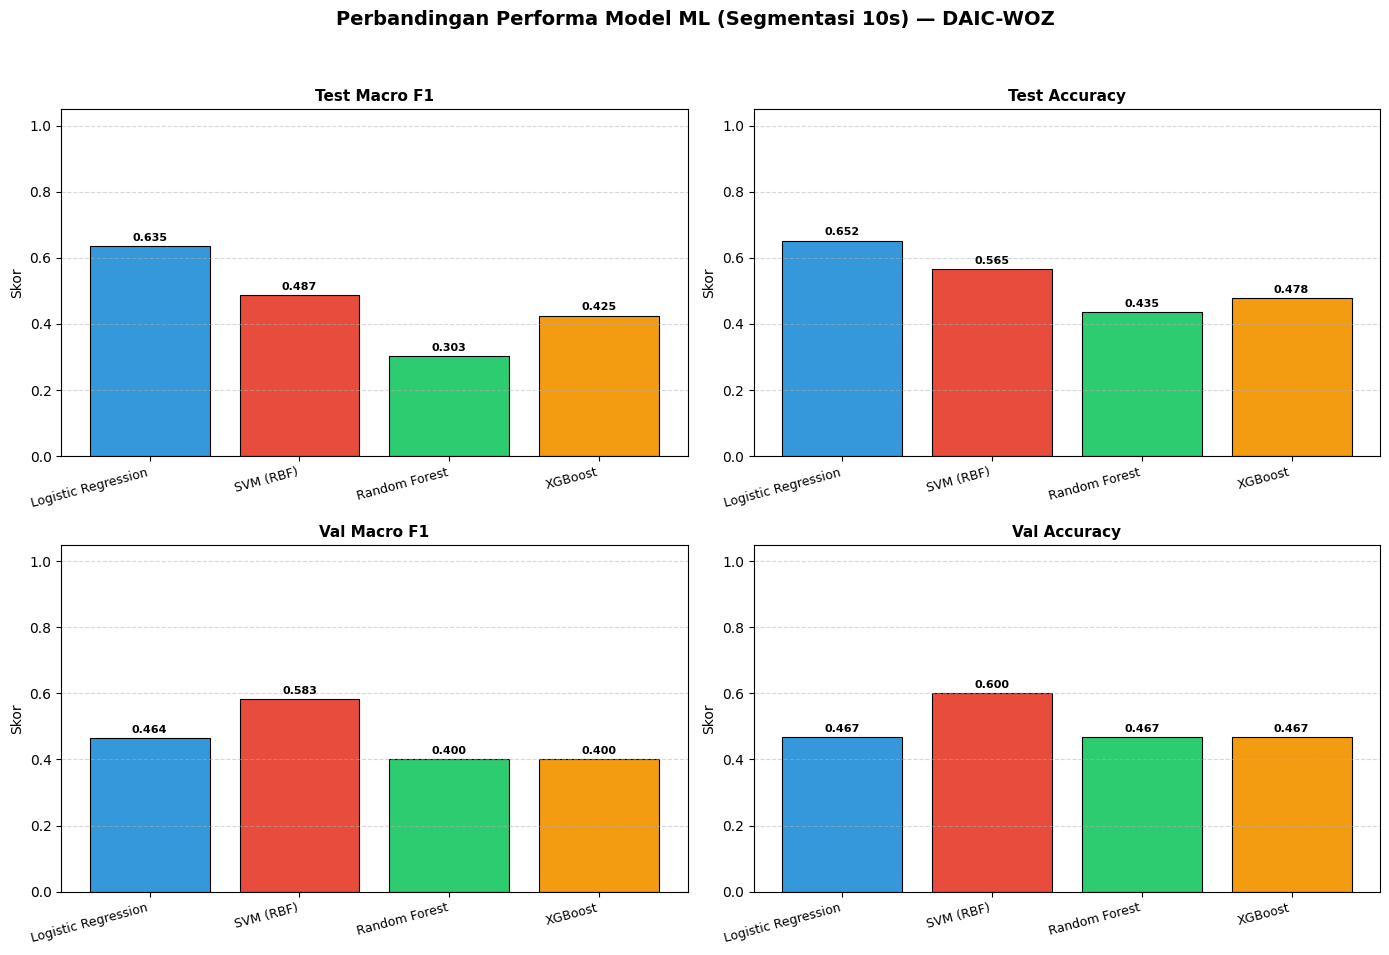

Plot perbandingan model disimpan di: d:\repositories\menthealth-ai\results\plots\daic_model_comparison_v3.png


In [10]:
# Visualisasi Perbandingan Model v3
metrics_to_plot = {
    'Test Macro F1': 'test_f1_macro',
    'Test Accuracy': 'test_accuracy',
    'Val Macro F1': 'val_f1_macro',
    'Val Accuracy': 'val_accuracy'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Performa Model ML (Segmentasi 10s) — DAIC-WOZ', fontsize=14, fontweight='bold')

model_names = list(results.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (title, col_name) in enumerate(metrics_to_plot.items()):
    ax = axes[idx // 2, idx % 2]
    values = [results[m][col_name] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', linewidth=0.8)
    
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Skor')
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
                
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plot_compare_path = os.path.join(RESULTS_DIR, "plots", "daic_model_comparison_v3.png")
fig.savefig(plot_compare_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot perbandingan model disimpan di: {plot_compare_path}")


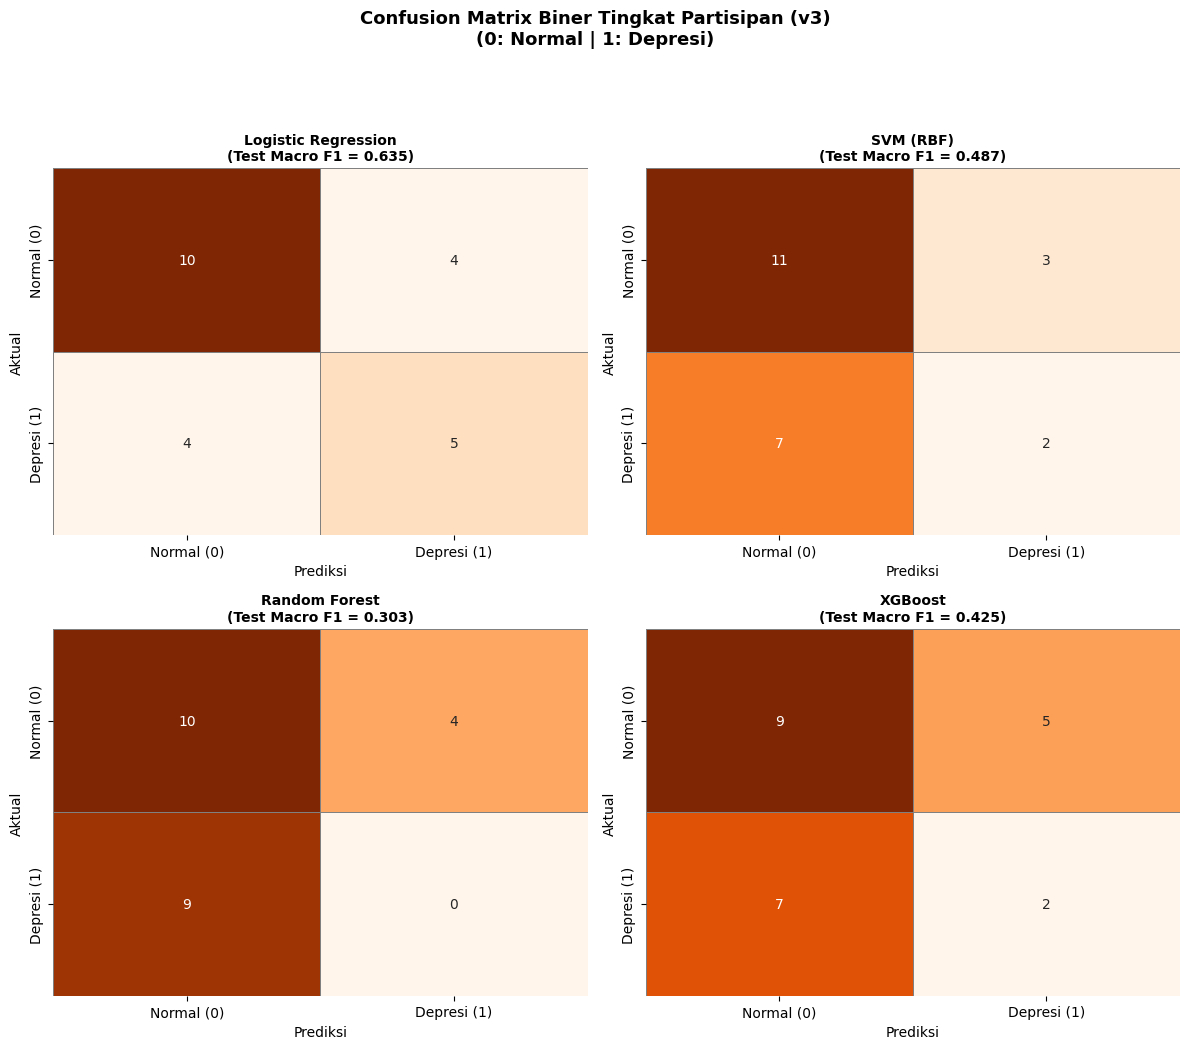

Plot confusion matrices disimpan di: d:\repositories\menthealth-ai\results\confusion_matrix\daic_confusion_matrices_v3.png


In [11]:
# Visualisasi Confusion Matrix tingkat partisipan untuk semua model v3
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle('Confusion Matrix Biner Tingkat Partisipan (v3)\n(0: Normal | 1: Depresi)', fontsize=13, fontweight='bold')

class_labels = ['Normal (0)', 'Depresi (1)']

for idx, (model_name, model) in enumerate(best_models.items()):
    ax = axes[idx // 2, idx % 2]
    y_true_test, y_pred_test = best_predictions[model_name]
    cm = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, linecolor='gray', cbar=False)
                
    f1 = results[model_name]['test_f1_macro']
    ax.set_title(f'{model_name}\n(Test Macro F1 = {f1:.3f})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
cm_plot_path = os.path.join(RESULTS_DIR, "confusion_matrix", "daic_confusion_matrices_v3.png")
fig.savefig(cm_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot confusion matrices disimpan di: {cm_plot_path}")


## 6. Pilih & Ekspor Model Terbaik v3


In [12]:
# Choose best model based on Test Macro F1 score
best_model_name_v3 = max(results, key=lambda m: results[m]['test_f1_macro'])
best_model_obj_v3 = best_models[best_model_name_v3]
best_metrics_v3 = results[best_model_name_v3]

print("\n" + "="*65)
print(f"  MODEL TERBAIK YANG DIPILIH (v3): {best_model_name_v3}")
print(f"  Test Macro F1                  : {best_metrics_v3['test_f1_macro']:.4f}")
print(f"  Test Accuracy                  : {best_metrics_v3['test_accuracy']:.4f}")
print("="*65)

print("\nClassification Report Model Terbaik (Tingkat Partisipan - v3):")
y_true_best_v3, y_pred_best_v3 = best_predictions[best_model_name_v3]
print(classification_report(y_true_best_v3, y_pred_best_v3, labels=[0, 1], target_names=class_labels, zero_division=0))

# Save models with _v3 suffix
for name, model in best_models.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    
    if 'svm' in safe_name:
        path = os.path.join(MODELS_DIR, "svm", "svm_v3.pkl")
    elif 'random_forest' in safe_name or 'forest' in safe_name:
        path = os.path.join(MODELS_DIR, "random_forest", "random_forest_v3.pkl")
    elif 'xgboost' in safe_name:
        path = os.path.join(MODELS_DIR, "xgboost", "xgboost_v3.pkl")
    else:
        path = os.path.join(MODELS_DIR, f"{safe_name}_v3.pkl")
        
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Model tersimpan di: {path}")

# Save best model metadata v3
best_info_v3 = {
    'best_model_name': best_model_name_v3,
    'best_params': best_metrics_v3['best_params'],
    'best_cv_f1': best_metrics_v3['best_cv_f1'],
    'test_f1_macro': best_metrics_v3['test_f1_macro'],
    'test_accuracy': best_metrics_v3['test_accuracy'],
    'feature_count': len(FEAT_COLS)
}

best_info_path_v3 = os.path.join(MODELS_DIR, "best_model_info_v3.json")
with open(best_info_path_v3, 'w') as f:
    json.dump(best_info_v3, f, indent=2)
print(f"Metadata model terbaik v3 disimpan di: {best_info_path_v3}")



  MODEL TERBAIK YANG DIPILIH (v3): Logistic Regression
  Test Macro F1                  : 0.6349
  Test Accuracy                  : 0.6522

Classification Report Model Terbaik (Tingkat Partisipan - v3):
              precision    recall  f1-score   support

  Normal (0)       0.71      0.71      0.71        14
 Depresi (1)       0.56      0.56      0.56         9

    accuracy                           0.65        23
   macro avg       0.63      0.63      0.63        23
weighted avg       0.65      0.65      0.65        23

Model tersimpan di: d:\repositories\menthealth-ai\models\ml\logistic_regression_v3.pkl
Model tersimpan di: d:\repositories\menthealth-ai\models\ml\svm\svm_v3.pkl
Model tersimpan di: d:\repositories\menthealth-ai\models\ml\random_forest\random_forest_v3.pkl
Model tersimpan di: d:\repositories\menthealth-ai\models\ml\xgboost\xgboost_v3.pkl
Metadata model terbaik v3 disimpan di: d:\repositories\menthealth-ai\models\ml\best_model_info_v3.json


## 7. Explainable AI (XAI) - SHAP & LIME (v3)


In [13]:
import shap
import lime
import lime.lime_tabular

XAI_DIR = os.path.join(RESULTS_DIR, "plots", "xai")

print("\n" + "="*65)
print(f"{'MEMULAI PENJELASAN MODEL v3 DENGAN XAI':^65}")
print("="*65)

# --- 1. SHAP untuk Random Forest ---
print("\n[SHAP] Memproses model Random Forest v3...")
try:
    rf_model = best_models['Random Forest']
    explainer_rf = shap.TreeExplainer(rf_model)
    # Gunakan X_test_scaled yang di-extract dari df_test segmen
    X_test_seg = df_test[FEAT_COLS].values
    X_test_seg_scaled = scaler.transform(X_test_seg)
    
    shap_values_rf = explainer_rf.shap_values(X_test_seg_scaled)
    
    if isinstance(shap_values_rf, list):
        rf_shap_disp = shap_values_rf[1]
    else:
        if len(shap_values_rf.shape) == 3:
            rf_shap_disp = shap_values_rf[:, :, 1]
        else:
            rf_shap_disp = shap_values_rf
            
    fig = plt.figure(figsize=(10, 6))
    shap.summary_plot(rf_shap_disp, X_test_seg_scaled, feature_names=FEAT_COLS, show=False)
    rf_summary_path = os.path.join(XAI_DIR, "shap_summary_rf_v3.png")
    plt.savefig(rf_summary_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  - Plot SHAP Summary RF v3 disimpan di: {rf_summary_path}")
    
    fig = plt.figure(figsize=(10, 6))
    shap.summary_plot(rf_shap_disp, X_test_seg_scaled, feature_names=FEAT_COLS, plot_type="bar", show=False)
    rf_bar_path = os.path.join(XAI_DIR, "shap_bar_rf_v3.png")
    plt.savefig(rf_bar_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  - Plot SHAP Bar (Feature Importance) RF v3 disimpan di: {rf_bar_path}")

    # Waterfall Plot untuk segmen pertama test set
    try:
        explainer_rf_exp = shap.Explainer(rf_model, X_train_scaled, feature_names=FEAT_COLS)
        shap_values_rf_exp = explainer_rf_exp(X_test_seg_scaled)
        
        if len(shap_values_rf_exp.shape) == 3:
            rf_exp_disp = shap_values_rf_exp[0, :, 1]
        else:
            rf_exp_disp = shap_values_rf_exp[0]
            
        fig = plt.figure(figsize=(10, 6))
        shap.plots.waterfall(rf_exp_disp, show=False)
        rf_waterfall_path = os.path.join(XAI_DIR, "shap_waterfall_rf_v3.png")
        plt.savefig(rf_waterfall_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  - Plot SHAP Waterfall RF v3 disimpan di: {rf_waterfall_path}")
    except Exception as e_wf:
        print(f"  - Bypass Waterfall RF v3: {e_wf}")
        
except Exception as e:
    print(f"  - Gagal memproses SHAP untuk Random Forest v3: {e}")

# --- 2. SHAP untuk XGBoost ---
print("\n[SHAP] Memproses model XGBoost v3...")
try:
    xgb_model = best_models['XGBoost']
    explainer_xgb = shap.TreeExplainer(xgb_model)
    shap_values_xgb = explainer_xgb.shap_values(X_test_seg_scaled)
    
    fig = plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_xgb, X_test_seg_scaled, feature_names=FEAT_COLS, show=False)
    xgb_summary_path = os.path.join(XAI_DIR, "shap_summary_xgb_v3.png")
    plt.savefig(xgb_summary_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  - Plot SHAP Summary XGBoost v3 disimpan di: {xgb_summary_path}")
    
    fig = plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_xgb, X_test_seg_scaled, feature_names=FEAT_COLS, plot_type="bar", show=False)
    xgb_bar_path = os.path.join(XAI_DIR, "shap_bar_xgb_v3.png")
    plt.savefig(xgb_bar_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  - Plot SHAP Bar XGBoost v3 disimpan di: {xgb_bar_path}")

    try:
        explainer_xgb_exp = shap.Explainer(xgb_model, X_train_scaled, feature_names=FEAT_COLS)
        shap_values_xgb_exp = explainer_xgb_exp(X_test_seg_scaled)
        
        fig = plt.figure(figsize=(10, 6))
        shap.plots.waterfall(shap_values_xgb_exp[0], show=False)
        xgb_waterfall_path = os.path.join(XAI_DIR, "shap_waterfall_xgb_v3.png")
        plt.savefig(xgb_waterfall_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  - Plot SHAP Waterfall XGBoost v3 disimpan di: {xgb_waterfall_path}")
    except Exception as e_wf:
        print(f"  - Bypass Waterfall XGBoost v3: {e_wf}")
        
except Exception as e:
    print(f"  - Gagal memproses SHAP untuk XGBoost v3: {e}")

# --- 3. LIME untuk SVM (RBF) ---
print("\n[LIME] Memproses model SVM (RBF) v3 menggunakan penjelasan lokal...")
try:
    svm_model = best_models['SVM (RBF)']
    
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled,
        feature_names=FEAT_COLS,
        class_names=['Normal', 'Depresi'],
        mode='classification',
        random_state=RANDOM_SEED
    )
    
    # Cari indeks segmen test set yang berlabel 1 (depresi)
    y_test_seg = df_test['label_depresi'].values
    test_idx = 0
    for i in range(len(y_test_seg)):
        if y_test_seg[i] == 1:
            test_idx = i
            break
            
    exp = explainer_lime.explain_instance(
        data_row=X_test_seg_scaled[test_idx],
        predict_fn=svm_model.predict_proba,
        num_features=10
    )
    
    fig = exp.as_pyplot_figure()
    lime_path = os.path.join(XAI_DIR, "lime_explanation_svm_v3.png")
    fig.savefig(lime_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  - Penjelasan LIME SVM v3 untuk Segmen ke-{test_idx} (Aktual: {'Depresi' if y_test_seg[test_idx]==1 else 'Normal'}) disimpan di: {lime_path}")
    
except Exception as e:
    print(f"  - Gagal memproses LIME untuk SVM v3: {e}")

print("="*65)

print("\n[OK] Pipeline ML v3 Selesai!")


             MEMULAI PENJELASAN MODEL v3 DENGAN XAI              

[SHAP] Memproses model Random Forest v3...
  - Plot SHAP Summary RF v3 disimpan di: d:\repositories\menthealth-ai\results\plots\xai\shap_summary_rf_v3.png
  - Plot SHAP Bar (Feature Importance) RF v3 disimpan di: d:\repositories\menthealth-ai\results\plots\xai\shap_bar_rf_v3.png
  - Bypass Waterfall RF v3: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.507229, while the model output was 0.527229. If this difference is acceptable you can set check_additivity=False to disable this check.

[SHAP] Memproses model XGBoost v3...
  - Plot SHAP Summary XGBoost v3 disimpan di: d:\repositories\menthealth-ai\results\plots\xai\shap_summary_xgb_v3.png
  - Plot SHAP Bar XGBoost v3 disimpa